# Predikcija zadovoljstva putnika avio-kompanije primenom neuronskih mreža i algoritama mašinskog učenja

Koristiće se:
- Logistička regresija
- Random Forest
- Višeslojna neuronska mreža (MLP)

# Biblioteke

In [114]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

In [115]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Priprema podataka

In [116]:
# Nepotrebne kolone uklanjamo
train_df.drop(columns=['id', 'Unnamed: 0'], inplace=True)
test_df.drop(columns=['id', 'Unnamed: 0'], inplace=True)

In [117]:
# Na osnovu zadnjih analiza, vidimo da su neke od kolona koje predstavljaju usluge avio kompanije imale vrednost 0, sto nije primenljivo. 
# Ove vrednosti cemo zameniti sa NaN, a zatim popuniti sa medianom.
service_cols = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

train_df[service_cols] = train_df[service_cols].replace(0, np.nan)
test_df[service_cols] = test_df[service_cols].replace(0, np.nan)
median = train_df[service_cols].median()

train_df[service_cols] = train_df[service_cols].fillna(median)
test_df[service_cols] = test_df[service_cols].fillna(median)

In [118]:
# Na osnovu korelacione matrice iz EDA, brišemo Arrival Delay in Minutes, jer je visoko korelisana sa Departure Delay in Minutes
train_df.drop(columns=['Arrival Delay in Minutes'], inplace=True)
test_df.drop(columns=['Arrival Delay in Minutes'], inplace=True)

In [119]:
# Kodiranje kategorickih kolona-One Hot Encoding
categorical_cols = [
    'Gender',
    'Customer Type',
    'Type of Travel',
    'Class'
]

train_df = pd.get_dummies(train_df, columns=categorical_cols, dtype=int , drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_cols, dtype=int , drop_first=True)

In [120]:
# Kako bi se osigurali da train i test skup imaju iste kolone nakon one hot encoding-a, koristimo align funkciju
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)


In [121]:
print("Kolone se poklapaju:", test_df.columns.equals(train_df.columns))

Kolone se poklapaju: True


In [122]:
le = LabelEncoder()

train_df['satisfaction'] = le.fit_transform(train_df['satisfaction'])
test_df['satisfaction'] = le.transform(test_df['satisfaction'])

In [123]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'neutral or dissatisfied': np.int64(0), 'satisfied': np.int64(1)}


In [124]:
# Train test split
X_train = train_df.drop('satisfaction', axis=1)
y_train = train_df['satisfaction']

X_test = test_df.drop('satisfaction', axis=1)
y_test = test_df['satisfaction']

In [125]:
num_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes']

scaler = StandardScaler()

# Skaliramo samo numeričke kontinualne kolone
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Random Forest

In [126]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96     14573
           1       0.97      0.93      0.95     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.95      0.96     25976
weighted avg       0.96      0.96      0.96     25976



Klasa 0: neutral/dissatisfied

Precision: Kada model kaže da je putnik nezadovoljan, u 95% slučajeva je u pravu

Recall: Model uspeva da pronađe čak 98% svih stvarno nezadovoljnih putnika

Klasa 1: satisfied

Precision: Model je precizan, 97% slucajeva pogodi da je putnik zadovoljan

Recall: Modelu promakne oko 7% zadovoljnih putnika

F1-score (0.96 i 0.95): Pošto su obe vrednosti izuzetno blizu, model je stabilan i podjednako dobro prepoznaje i jedne i druge putnike

In [127]:
importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(10))

                           feature  importance
7                  Online boarding    0.209368
19  Type of Travel_Personal Travel    0.111238
2            Inflight wifi service    0.109857
20                       Class_Eco    0.073775
9           Inflight entertainment    0.055330
8                     Seat comfort    0.047304
1                  Flight Distance    0.040447
11                Leg room service    0.037800
0                              Age    0.036703
10                On-board service    0.033598


C:\Users\Irina\AppData\Local\Temp\ipykernel_10044\187285070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='importance', y='feature', data=feat_imp.head(10), palette='viridis')


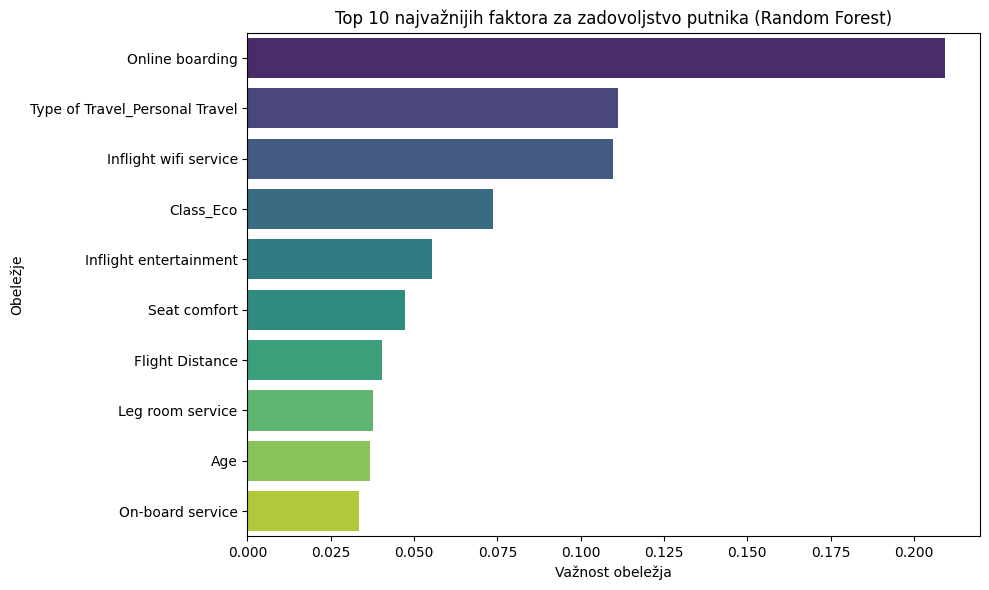

In [129]:
plt.figure(figsize=(10, 6))
sb.barplot(x='importance', y='feature', data=feat_imp.head(10), palette='viridis')
plt.title('Top 10 najvažnijih faktora za zadovoljstvo putnika (Random Forest)')
plt.xlabel('Važnost obeležja')
plt.ylabel('Obeležje')
plt.tight_layout()
plt.show()

# Osnovna MLP neuronska mreža